# Sample Size & Significance

Assume now that we have a very small effect size. For instance, assume we have two groups, 

$X - Y$, that are both normally distributed with variance 1.

But $E[X] = \mu_X = 0$ and $E[Y] = \mu_Y = 0.01$

We sample from these distribution and do a $t$-test try to reject the null hypothesis that $E[X] = E[Y]$. (i.e. the effect size is exactly $0$)



If our sample size is small, e.g., $n_x = n_y = 10$, the difference in means is unlikely to be statistically significant.

In [18]:
import pandas as pd 
import numpy as np
import seaborn as sns
from plotnine import *

mu_x = 0
mu_y = 0.01
n = 10

In [19]:
x = np.random.normal(loc = mu_x, scale= 1, size = n)
y = np.random.normal(loc = mu_y, scale= 1, size = n)

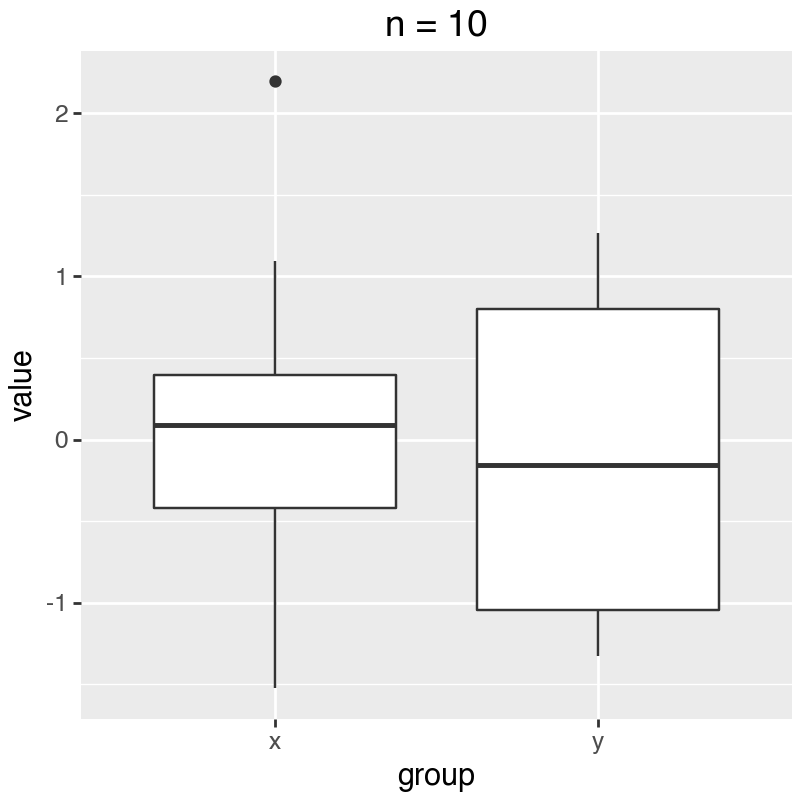

In [20]:
dt = pd.DataFrame({
    'value': np.concatenate([x,y]),
    'group': np.repeat(['x','y'],n)
})

(
    ggplot(dt, aes(x = 'group', y = 'value')) +
    geom_boxplot() +
    labs(title = f'n = {n}') + 
    theme(figure_size= (4,4))
)

In [21]:
from scipy.stats import ttest_ind

ttest_ind(dt[dt['group'] == 'x']['value'], dt[dt['group'] == 'y']['value'], equal_var= False).pvalue

np.float64(0.5734133052667607)

But things change as we start to increase the sample size:

In [22]:
ns = np.round(np.logspace(1, 6, 100)).astype(int)
ns

array([     10,      11,      13,      14,      16,      18,      20,
            23,      25,      28,      32,      36,      40,      45,
            51,      57,      64,      72,      81,      91,     102,
           115,     129,     145,     163,     183,     206,     231,
           260,     292,     327,     368,     413,     464,     521,
           586,     658,     739,     830,     933,    1048,    1177,
          1322,    1485,    1668,    1874,    2105,    2364,    2656,
          2984,    3352,    3765,    4229,    4751,    5337,    5995,
          6734,    7565,    8498,    9545,   10723,   12045,   13530,
         15199,   17074,   19179,   21544,   24201,   27186,   30539,
         34305,   38535,   43288,   48626,   54623,   61359,   68926,
         77426,   86975,   97701,  109750,  123285,  138489,  155568,
        174753,  196304,  220513,  247708,  278256,  312572,  351119,
        394421,  443062,  497702,  559081,  628029,  705480,  792483,
        890215, 1000

In [23]:
pvs = []

for n in ns:
    x = np.random.normal(loc = mu_x, scale = 1, size = n)
    y = np.random.normal(loc = mu_y, scale = 1, size = n)
    
    p_val = ttest_ind(x,y, equal_var= False).pvalue
    pvs.append(p_val)

dt = pd.DataFrame({
    'n':ns,
    'p_value': pvs
})

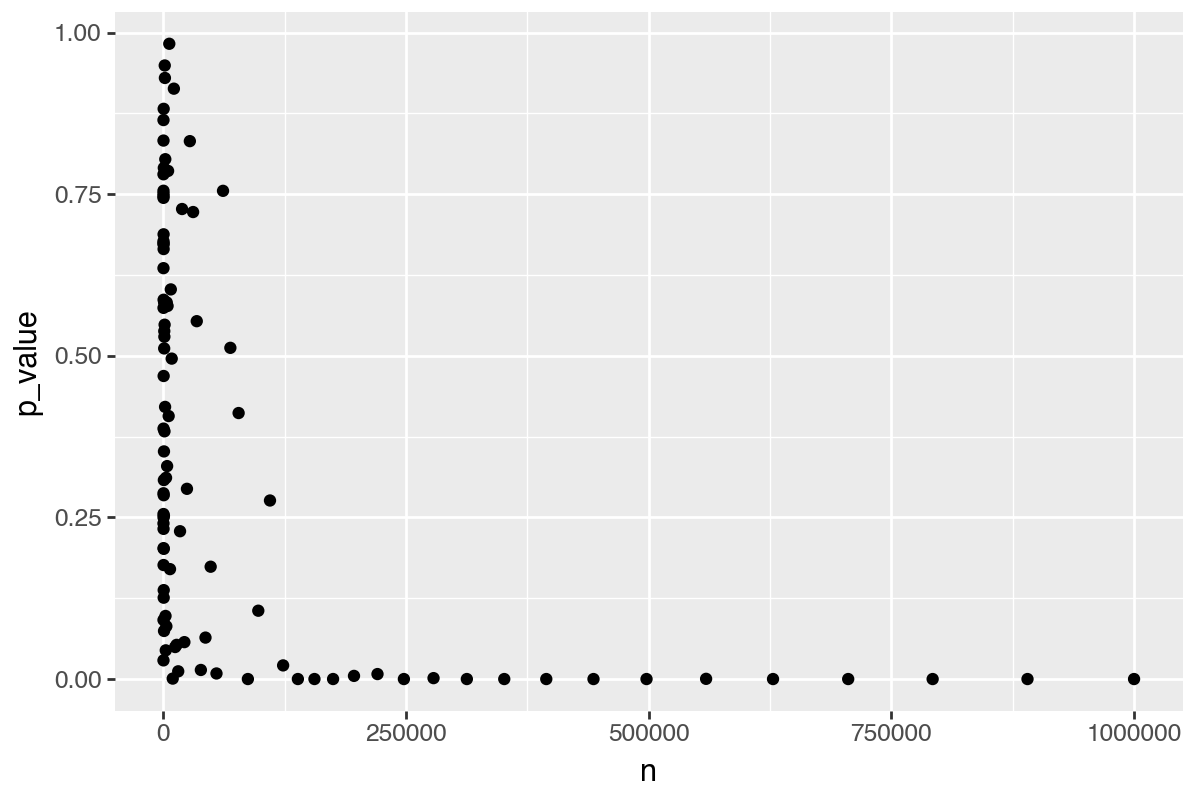

In [24]:
(
    ggplot(dt, aes(x = 'n', y = 'p_value')) + 
    geom_point() + 
    theme(figure_size= (6,4))
)

We see that as the sample size gets bigger and bigger, the $P$-values quickly drop.

Once we have a million observations, we can easily reject the null hypothesis that the true effect is zero:

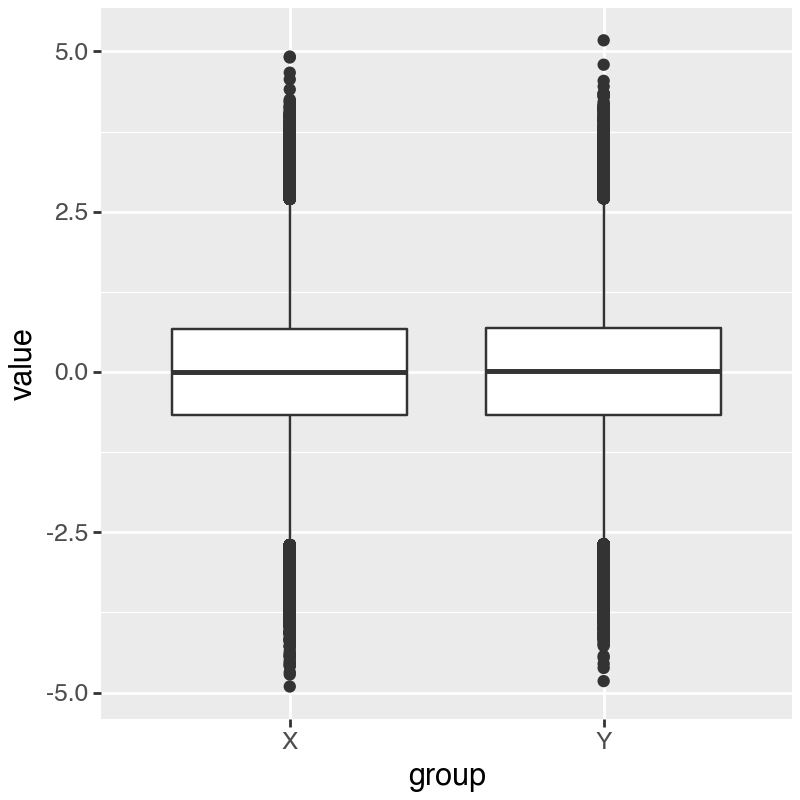

In [25]:
x = np.random.normal(loc = 0, scale = 1, size = int(1e6))
y = np.random.normal(loc = 0.01, scale = 1, size = int(1e6))

df = pd.DataFrame({
    'value' : np.concatenate([x,y]),
    'group' : np.repeat(['X','Y'], int(1e6))
})

(
    ggplot(df, aes(x = 'group', y = 'value')) + 
    geom_boxplot() +
    theme(figure_size= (4,4)) 
)

The conclusion is that, as the sample size grows, any true effect, no matter how small, will be detected.

This creates a problem. In reality, the null hypothesis, will seldom be literally true. Because we live in a complex and interconnected world, many variables will be somewhat correlated, even if the correlation is very weak. The effect size will rarely be exactly $0.0$.

This means, if our dataset is big enough (i.e. many hundreds of thousands of datapoints), it is likely that whatever association we test, it will be significant. But many of these associations will likely be too small to be of any practical importance.

------

### Report P-Val, effect size, and plot

Because of this, only reporting that an association is statistically significant is misleading and not particularly helpful. To avoid this problem, we should always report the $P$
-value, an estimate of the effect size and a plot of our data that supports our conclusions.



------

# Multiple Testing

In addition to the problem of detecting very small effects, big data also poses the problem of detecting false effects due to `multiple testing`. We will first discuss why multiple testing can undermine the conclusions we derive from data. Then we will explore ways to guard against being mislead in this way, using a simulated dataset as an example.

## Multiple testing in real life: $P$-Hacking and fishing expeditions

Expressed very simply, multiple testing refers to the issue that, if we test enough hypotheses at a given significance level, say $\alpha = 0.05$
, we are bound to eventually get a significant result, even if the null hypothesis is always true.

Multiple testing is an ever-present problem also in real life data analysis. <u>It appears particularly once we start stratifying large datasets into subgroups, testing a seperate hypothesis for each one.</u>

Say we want to test the effect of a new medication. We find it has no effect in the general population. But maybe it only works in women? Maybe it affects people of different ages differently? Maybe smokers metabolize it differently to non-smokers? If our data is large enough and we keep stratifying it into subgroups, we are bound to find one where $P < 0.05$, even if our medication is completely useless.

# The Land of Counterfeit (fake) coins

To see multiple testing in action on a concrete example, and to explore ways to correct for it, we simulate a dataset based on flipping coins. We will tell a little fairytale to make the details less dry:

Long, long ago, in a country far far away, a king suspected counterfeit coins were circulating in his kingdom. Original coins were fair: When tossed, each coin has an equal chance to come up heads or tails. Counterfeits instead were more biased towards more heads. The king requested each one of his 1,000 subjects to toss his or her coin (subjects owned only one coin) 20 times.



## Simulation

Here we simulate data for this scenario. 

We (not the king/queen) know that in reality $90\%$ of the subjects own a fair coin. 

For simplicity, we assume that all counterfeits have probability $0.8$ for the head.

In [26]:
np.random.seed(10)

m = 1000          # subjects
m0 = int(0.9 * m) # subjects with fair coins
n = 20            # the times of subjects will toss their coin


fair = np.array(['fair'] * m0 + ['biased'] * (m - m0))
probs = np.where(fair == 'fair', 0.5, 0.8) 

heads = np.random.binomial(n, probs) 


dt = pd.DataFrame({
    'fair': fair,
    'heads': heads
})

dt

,fair,heads
0,fair,12
1,fair,6
2,fair,11
3,fair,12
4,fair,10
...,...,...
995,biased,16
996,biased,17
997,biased,18
998,biased,15


We look now at the distribution of heads for the fair and the biased coins.

In [27]:
dt2 = dt.groupby(['fair', 'heads']).size().reset_index(name = 'N')
dt2

,fair,heads,N
0,biased,12,1
1,biased,13,6
2,biased,14,10
3,biased,15,17
4,biased,16,17
5,biased,17,24
6,biased,18,20
7,biased,19,5
8,fair,4,7
9,fair,5,19


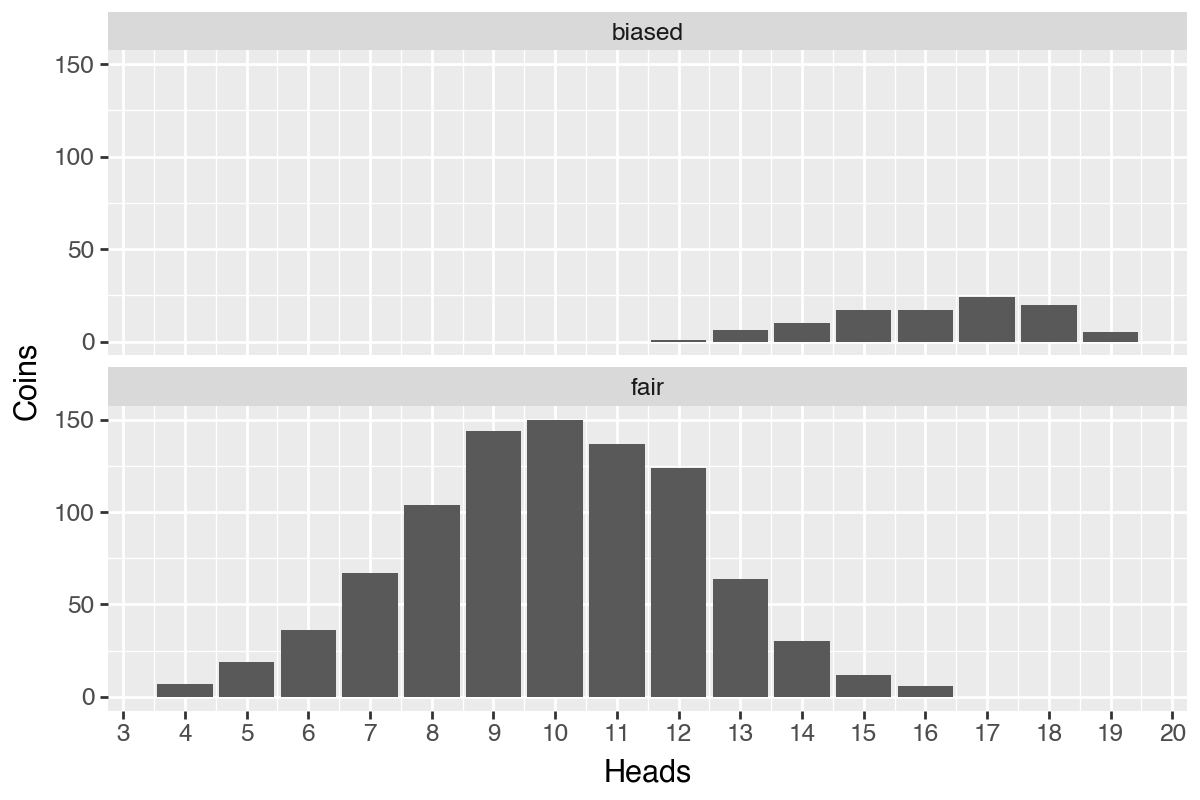

In [28]:
(
    ggplot(dt2, aes(x = 'heads', y ='N')) + 
    geom_bar(stat = 'identity') +
    facet_wrap('~fair',nrow=2) +
    scale_x_continuous(name = 'Heads', breaks= range(n+1)) + 
    scale_y_continuous(name = 'Coins') + 
    theme(figure_size=(6,4))
)

## Nominal $P$-Value 

The king declares: 

“I presume innocence, i.e. I will consider the null hypothesis that each coin is fair. I will reject this hypothesis using a one-sided binomial test at 
$P$-value $\leq$ 0.05.”



The king computes the $P$-values.

In [29]:
from scipy.stats import binomtest

dt['p_value'] = dt['heads'].apply(lambda x: binomtest(x, n=n, p=0.5, alternative='greater').pvalue)
dt

,fair,heads,p_value
0,fair,12,0.251722
1,fair,6,0.979305
2,fair,11,0.411901
3,fair,12,0.251722
4,fair,10,0.588099
...,...,...,...
995,biased,16,0.005909
996,biased,17,0.001288
997,biased,18,0.000201
998,biased,15,0.020695


We can compute the number of rejected tests:

In [30]:
(dt['p_value'] <= 0.05).sum()

np.int64(101)

The king is furious. There are $101$ declared guilty. He requests the death penalty for all of them.

### Explanation:

nominal $P$-values can lead to many false rejections when testing multiple hypotheses

Since we (simulators) know the truth, we can compute the contingency table of rejected tests versus the ground truth:

In [31]:
pd.crosstab(dt['fair'], dt['p_value'] <= 0.05, colnames=['rejected'])

rejected,False,True
fair,,
biased,17,83
fair,882,18


We see that this will mean that 18 innocent subjects will be punished, despite the fact that the King used rigorous statistical testing against a null hypothesis of innocence to establish guilt. What went wrong?

To explore what is happening here, we first need to note a very important fact about 
$P$-values: under the null hypothesis, we have that $p(P < \alpha | H_0) = \alpha$
.

To see why, let us first recall the definition of the $P$-value:

it is the probability of obtaining a test statistic the same as or more extreme than the one we actually observed, under the assumption that the null hypothesis is true. 

Assume, for simplicity, we are doing a right-tailed one-sided test. The $P$ -value is:

$P = p(T \geq T_{obs} | H_0)$

Let $T_{0.05}$ be a test statistic just big enough so that:

$0.05 = p(T \geq T_{0.05} | H_0)$

Now, given this definition, what is the probability under the null hypothesis of getting $P < 0.05$ ? 

Well, to get a $P$-value smaller than $0.05$, we need to observe a test statistic $T$
 bigger than $T_{0.05}$
. And we know that under the null hypothesis the probability of that happening is:

$p(T \geq T_{0.05} | H_0)$

which we just said is equal to $0.05$! 

So $p(P < 0.05 | H_0) = 0.05$

, and the same logic generalizes for any other $\alpha \in [0,1]$.

This, in turn, means that when we test 900 fair coins and reject the null hypothesis that the coin is fair whenever 
$P < 0.05$, then on average we will reject the null hypothesis about $5\%$
of the time, 
 
so $900 * 0.05 = 45$ times.

Thus, in some sense the King actually got lucky that he “only” falsely accused 18.

Another way of stating this fact is to say that, under the null hypothesis, the $P$
-value follows a uniform distribution on the $[0,1]$ interval. 

Figure illustrates the $P$
-value distribution, compared to the $[0,1]$
uniform distribution, for the fair and for the biased coins:

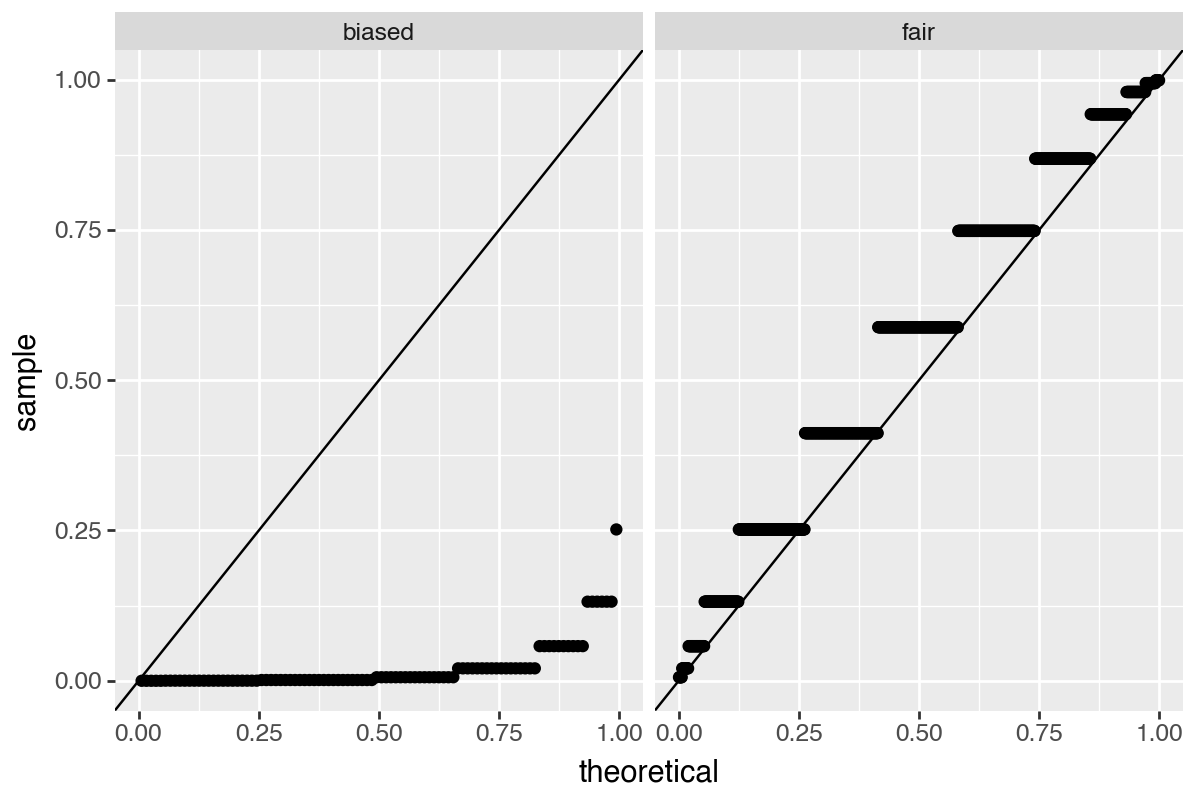

In [32]:
(
    ggplot(dt, aes(sample = 'p_value')) +
    geom_qq(distribution = 'uniform') + 
    facet_wrap('fair') + 
    geom_abline(slope = 1, intercept = 0) + 
    theme(figure_size=(6,4))
)

We see that the $p$
-values for the fair coins match the uniform distribution quite well (values along diagonal). In contrast, the $p$ 
-values for the biased coins are excessively small compared to the uniform distribution. This is exactly what we want: small $p$-
values when the null hypothesis does not hold. (Note that the distribution of $p$-
values for discrete statistics actually shows these stairs due to ties. One could visually fix it but this is not a major point).

## Bonferroni Correction Family Wise Error Rate

The queen, who is well-versed in matters of probability, is rightfully appalled at the prospect of many innocent subjects being executed.

She states: 

“If they were all innocent, you would declare $0.05 * 1000 = 50$ subjects guilty and falsely sentence them to death. We shall not accept that any innocent person is killed”.

King: 

“Mmmh, good point. But we cannot be $100\%$ sure. What if I make sure that there is at most $5\%$ chance that an innocent person is mistakenly killed?”

Queen: 

“Fine.”

Now the King must control such that the probability that one or more innocent is killed is smaller than $5\%$. 

He uses Bonferroni correction, which amounts to multiplying the $P$
-values by $m=1,000$ or setting them to $1$, whichever is smaller (because probability can’t be larger than 1).

In [33]:
from statsmodels.sandbox.stats.multicomp import multipletests

dt['bonferroni'] = multipletests(dt['p_value'], method = 'bonferroni')[1]

dt

,fair,heads,p_value,bonferroni
0,fair,12,0.251722,1.000000
1,fair,6,0.979305,1.000000
2,fair,11,0.411901,1.000000
3,fair,12,0.251722,1.000000
4,fair,10,0.588099,1.000000
...,...,...,...,...
995,biased,16,0.005909,1.000000
996,biased,17,0.001288,1.000000
997,biased,18,0.000201,0.201225
998,biased,15,0.020695,1.000000


Here is the new contingency table. In this case, no innocent person was killed (He did kill 5 guilty people). It could have happened, though, but with less than 5% chance.

In [35]:
pd.crosstab(dt['fair'], dt['bonferroni'] <= 0.05, colnames=['rejected'])


rejected,False,True
fair,,
biased,95,5
fair,900,0


### Explanation: 

To understand how the correction the King applied works, and why it makes sense, we first introduce some notation:

<img src = 'images/Büyük Veri İstatistik Değerlendirmeleri.png' width = 700>

The Queen wants to keep $V$, the number of true null hypotheses which were falsely rejected (leading to an innocent being executed), as low as possible. The King can do that by controlling the so-called Family-wise error rate:

#### Family-wise error rate (FWER):

$p(V>0)$ , the probability of one or more false positives (i.e. the probability of one or more innocent being executed).

Specifically, the King has opted to keep the FWER below $\alpha = 0.05$.

We have just established that, under the null hypothesis, if we do $m$
tests, and reject if $P < \alpha$, then we will falsely reject about $m\alpha$
times. 

To control the FWER, the so-called Bonferroni correction is a lot more demanding, and only reject if 

$P < \frac{\alpha}{m}$

More formally, suppose we conduct our $m$ hypothesis tests for each $g = 1,...,m$, producing each a $P$-value $P_g$. 

Then the Bonferroni-adjusted $P$-values are:

$\tilde{P}_g = \min\{ m P_g, 1 \}$

Selecting all tests with $\tilde{P} < \alpha$ controls the FWER at level $\alpha$, i.e., $P(V>0) \leq \alpha$


In Python we can adjust the $P$-values using the 

`statsmodels.stats.multitest.multipletests`

package: `multipletests(dt['p_value'], method='bonferroni')`

The proof goes as follows. We assume to have applied Bonferroni correction, i.e. that we have rejected all hypotheses $i$ such that $P_i < \frac{\alpha}{m}$.

We then start from the definition: <b>FWER</b> = $p(V > 0)$ which is the probability that at least one of the true null hypotheses got rejected:

<b>FWER</b> = $p(V>0)$

= $p(\{ H_{0,1} \text{ rejected}\} \text{ or  } \{ H_{0,2} \text{ rejected}\} \text{ or  } ... \{ H_{0,m_0} \text{ rejected}\}$

Now, among a set of binary random events (here rejection, or not, of each true null hypothesis), the probability that at least one random event realizes is less than or equal to the sum of the probabilities of each random event to realize.

It would be equal to the sum, only if those events were mutually exclusive. We cannot exclude the possibility that rejections of the true null hypotheses are mutually exclusive although in practice this is a very conservative assumption. So, conservatively, we have the following upper bound:

<b>FWER</b> $\leq \sum_i^{m_0}{p(H_{0,i} \text{ rejected })}$

What is $p(H_{0,i} \text{ rejected })$ when $i = 1,...,m_0$

i.e., when $i$  is the index of a true null hypothesis? Having applied Bonferroni’s correction means that, for all $i$:

$p(H_{0,i} \text{ rejected })$ = $p(P_i \leq \frac{\alpha}{m})$

Moreoever, by definition of the $P$-value, we have that $p(P_i \leq \frac{\alpha}{m}) = \frac{\alpha}{m}$ for all $i = 1,...,m_0$, as these are the indices of the true null hypotheses. Hence we get: 

<b>FWER</b> $\leq m_0\frac{\alpha}{m} \leq \alpha$

This shows that the Bonferroni correction controls the FWER at the level $\alpha$.

This control does not require any assumption about dependence among the $P$-values or about how many of the null hypotheses are true. 

The drawback is that it is very conservative. If we run 1,000 tests at $\alpha = 0.05$
, we will only reject if the (unadjusted) $P$
-value is smaller than $0.00005$

## False Discovery Rate

King:” If they were all innocent as you assumed, there should have been 50 with a $P$
value less than 0.05 in the first place. 

But they were instead 101. There are still a lot of counterfeiters unpunished. What if I introduced a fine rather than the death penalty?”

Queen: “That is more reasonable. It would be tolerable that <b>no more</b> than 5% of fined subjects are <b>actually innocent.</b>”

The king now needs to control for the proportion of innocent people among the subjects called guilty (rejected = True). He uses the False Discovery Rate with Benjamini-Hochberg correction. This controls the expected value of that proportion.

In [36]:
dt['BH'] = multipletests(dt['p_value'], method='fdr_bh')[1]
dt

,fair,heads,p_value,bonferroni,BH
0,fair,12,0.251722,1.000000,0.749174
1,fair,6,0.979305,1.000000,0.998712
2,fair,11,0.411901,1.000000,0.870828
3,fair,12,0.251722,1.000000,0.749174
4,fair,10,0.588099,1.000000,0.943978
...,...,...,...,...,...
995,biased,16,0.005909,1.000000,0.082069
996,biased,17,0.001288,1.000000,0.026294
997,biased,18,0.000201,0.201225,0.008049
998,biased,15,0.020695,1.000000,0.204898


In [37]:
pd.crosstab(dt['fair'], dt['BH'] <= 0.05, colnames=['rejected'])

rejected,False,True
fair,,
biased,51,49
fair,900,0


A higher number of counterfeiters were discovered, while the proportion of innocents among the subjects declared guilty (0 out of 49) remained lower than about 5%.

### Explanation

When applying the Bonferroni correction, we took a very conservative view: we created a worst-case scenario where <u><b>everyone</b> was innocent</u>, and then minimized the probability of innocents being executed based on this assumption.

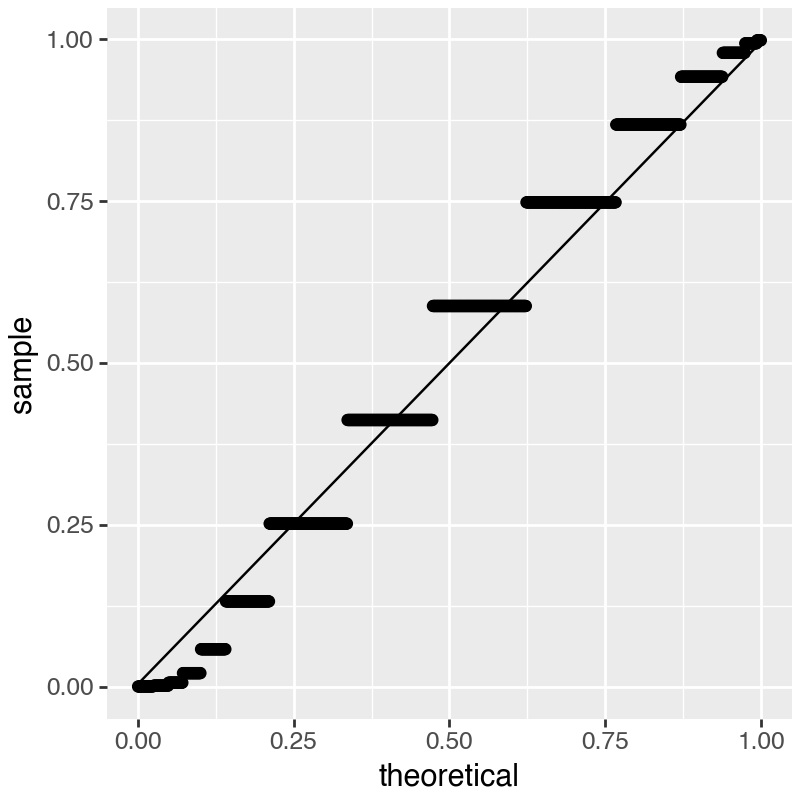

In [50]:
(
    ggplot(dt, aes(sample='p_value')) +
    stat_qq(distribution='uniform') +
    stat_qq_line(distribution='uniform') + 
    theme( figure_size=(4,4))
)


We notice a deviation from the assumption of uniformity at the low end of the distribution. This is due to the presence of the guilty subjects, whose coins do not obey the null hypothesis (the entire population is a mixture of fair and unfair coins, whose respective Q-Q plots are shown)

Controlling the <u>Family-wise error rate ensures we have few false positives, but it comes at the cost of many false negatives</u>.

Instead of conservatively minimizing the probability of false positives, the Benjamini-Hochberg correction takes a more balanced view and instead controls the so-called <u>False discovery rate (FDR)</u> defined as the expected fraction of false positives among all discoveries:

<img src = 'images/Büyük Veri İstatistik Değerlendirmeleri.png' width = 700>

$FDR = E[\frac{V}{max(R,1)}]$

To do this, we first order our (unadjusted) $P$-values. 

Let the ordered unadjusted $P$
-values be: $P_1 \leq P2 \leq ... \leq P_m$
. Let $j$
 refer to a rank in this ordering, so $P_j$
 is the j-th smallest $P$
-value, and $H_{0,j}$
 is the respective null hypothesis.



To control the $FDR$ at level $\alpha$, we let:

$j^* = max\{j: P_j \leq \frac{j\alpha}{m}\}$

And we reject $H_{0,j}$ if $j \leq j^*$

<u>Why does this control the FDR?</u>

We say there are $m_0$
 hypotheses where $H_{0,j}$
 is true (in our example $m_0 = 900$
, out of $m = 1000$
 tests we conduct).

As we discussed, when $H_0$
 is true, the corresponding $P$ 
-value follows a uniform distribution (assuming independence).

This means that on average $m_0 \frac{j^*\alpha}{m} P$ -values of true null hypotheses will fall into the interval $[0,m_0 \frac{j^*\alpha}{m}]$ In other words, we expect:

$m_0 \frac{j^*\alpha}{m}$

false rejections.

Over all, we reject $j^*$ times.

Thus we get an FRD of:

$\frac{m_0\frac{j^*\alpha}{m}}{j^*} = \frac{m_0}{m}\alpha \leq \alpha$

The Benjamini-Hochberg correction is valid for independent test statistics and some types of dependence